# **DataManipulation**

In [2]:
import pandas as pd
import numpy as np

Querying (filter) : rows/observations

In [3]:
df = pd.DataFrame({'A': range(1, 6),
                   'B': range(10, 0, -2),
                   'C C': range(10, 5, -1)})
df

,A,B,C C
0,1,10,10
1,2,8,9
2,3,6,8
3,4,4,7
4,5,2,6


In [4]:
df.query('B == `C C`')

,A,B,C C
0,1,10,10


In [5]:
#Ex1
n = 10
df = pd.DataFrame(np.random.rand(n, 3), columns=list('abc'))
df

,a,b,c
0,0.126209,0.941745,0.516681
1,0.805153,0.809116,0.419752
2,0.095262,0.901523,0.073588
3,0.665177,0.511485,0.534608
4,0.617091,0.005477,0.119389
5,0.236500,0.192580,0.734245
6,0.405894,0.024716,0.881091
7,0.267301,0.960219,0.715555
8,0.857810,0.557260,0.227730
9,0.758539,0.953533,0.981478


In [6]:
#pure python
df[(df['a'] < df['b']) & (df['b'] < df['c'])]

,a,b,c
9,0.758539,0.953533,0.981478


In [7]:
#query() method that allows selection using an expression.
df.query('(a < b) & (b < c)')

,a,b,c
9,0.758539,0.953533,0.981478


In [8]:
#Ex2
df = pd.DataFrame(np.random.randint(n, size=(n, 2)), columns=list('bc'))

df

,b,c
0,2,3
1,8,6
2,0,8
3,2,5
4,6,7
5,7,3
6,2,0
7,3,8
8,4,8
9,0,6


In [9]:
df.query('index < b < c')

,b,c
0,2,3
4,6,7


Sorting (arrange) : rows/observations

In [10]:
df = pd.DataFrame({
    'col1': ['A', 'A', 'B', np.nan, 'D', 'C'],
    'col2': [2, 1, 9, 8, 7, 4],
    'col3': [0, 1, 9, 4, 2, 3],
    'col4': ['a', 'B', 'c', 'D', 'e', 'F']
})
df

,col1,col2,col3,col4
0,A,2,0,a
1,A,1,1,B
2,B,9,9,c
3,NaN,8,4,D
4,D,7,2,e
5,C,4,3,F


In [11]:
#Sort by col1
df.sort_values(by=['col1','col2'])

,col1,col2,col3,col4
1,A,1,1,B
0,A,2,0,a
2,B,9,9,c
5,C,4,3,F
4,D,7,2,e
3,NaN,8,4,D


In [12]:
#Sort by multiple columns
df.sort_values(by=['col1', 'col2'])

,col1,col2,col3,col4
1,A,1,1,B
0,A,2,0,a
2,B,9,9,c
5,C,4,3,F
4,D,7,2,e
3,NaN,8,4,D


In [13]:
#Sort Descending
df.sort_values(by='col1', ascending=False)

,col1,col2,col3,col4
4,D,7,2,e
5,C,4,3,F
2,B,9,9,c
0,A,2,0,a
1,A,1,1,B
3,NaN,8,4,D


In [14]:
#Putting NAs first
df.sort_values(by='col1', ascending=False, na_position='first')

,col1,col2,col3,col4
3,NaN,8,4,D
4,D,7,2,e
5,C,4,3,F
2,B,9,9,c
0,A,2,0,a
1,A,1,1,B


In [15]:
#Sorting with a key functionD
df.sort_values(by = 'col4'  , key=lambda col: col.str.lower())

,col1,col2,col3,col4
0,A,2,0,a
1,A,1,1,B
2,B,9,9,c
3,NaN,8,4,D
4,D,7,2,e
5,C,4,3,F


In [16]:
#Sorting with a key functionD
df.sort_values(by = 'col4')

,col1,col2,col3,col4
1,A,1,1,B
3,NaN,8,4,D
5,C,4,3,F
0,A,2,0,a
2,B,9,9,c
4,D,7,2,e


Transforming (select) : columns/varaibles

In [17]:
df = pd.DataFrame([[1, 2], [4, 5], [7, 8]],
     index=['cobra', 'viper', 'sidewinder'],
     columns=['max_speed', 'shield'])
df

,max_speed,shield
cobra,1,2
viper,4,5
sidewinder,7,8


In [18]:
#Single label. Note this returns the row as a Series.
df.loc['viper']

max_speed    4
shield       5
Name: viper, dtype: int64

In [19]:
#List of labels. Note using [[]] returns a DataFrame.
df.loc[['viper', 'sidewinder']]

,max_speed,shield
viper,4,5
sidewinder,7,8


In [20]:
#Single label for row and column
df.loc['cobra', 'shield']

np.int64(2)

In [21]:
#Setting values
#Set value for all items matching the list of labels


df.loc[['viper', 'sidewinder'], ['shield']] = 50
df



,max_speed,shield
cobra,1,2
viper,4,50
sidewinder,7,50


In [22]:
#Set value for an entire row
df.loc['cobra'] = 10
df

,max_speed,shield
cobra,10,10
viper,4,50
sidewinder,7,50


In [23]:
#Set value for an entire column

df.loc[:, 'max_speed'] = 30
df

,max_speed,shield
cobra,30,10
viper,30,50
sidewinder,30,50


Transforming (rename) : columns/varaibles

In [24]:
df = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})
df

,A,B
0,1,4
1,2,5
2,3,6


In [25]:
#Rename columns using a mapping
df.rename(columns={"A": "a", "B": "c"})

,a,c
0,1,4
1,2,5
2,3,6


In [26]:
#Rename index using a mapping
df.rename(index={0: "X", 1: "Y", 2: "Z"})

,A,B
X,1,4
Y,2,5
Z,3,6


In [27]:
#Cast index labels to a different type
df.index

RangeIndex(start=0, stop=3, step=1)

In [28]:
df.rename(index=str).index

Index(['0', '1', '2'], dtype='str')

In [29]:
#df.rename(columns={"A": "a", "B": "b", "C": "c"}, errors="raise")
df.rename(columns={"A": "a", "B": "b"}, errors="raise")

,a,b
0,1,4
1,2,5
2,3,6


In [30]:
df.rename(str.lower, axis='columns')

,a,b
0,1,4
1,2,5
2,3,6


In [31]:
df.rename({1: 2, 2: 4}, axis='index')

,A,B
0,1,4
2,2,5
4,3,6


Transforming (mutate) : columns/varaibles



In [32]:
#Assigning multiple columns within the same assign is possible.
df = pd.DataFrame({'temp_c': [17.0, 25.0]},
                  index=['Portland', 'Berkeley'])
df

,temp_c
Portland,17.0
Berkeley,25.0


In [33]:
#achieved by directly referencing an existing Series or sequence
df.assign(temp_f = df['temp_c'] * 9 / 5 + 32)

,temp_c,temp_f
Portland,17.0,62.6
Berkeley,25.0,77.0


In [34]:
#alternative way
df.assign(temp_f=lambda x: x.temp_c * 9 / 5 + 32)

,temp_c,temp_f
Portland,17.0,62.6
Berkeley,25.0,77.0


In [35]:
df.assign(temp_f=lambda x: x['temp_c'] * 9 / 5 + 32,
          temp_k=lambda x: (x['temp_f'] +  459.67) * 5 / 9)

,temp_c,temp_f,temp_k
Portland,17.0,62.6,290.15
Berkeley,25.0,77.0,298.15


Grouping and summarizing (group by)

In [36]:
df = pd.DataFrame({'Animal': ['Falcon', 'Falcon',
                              'Parrot', 'Parrot'],
                   'Max Speed': [380., 370., 24., 26.]})
df

,Animal,Max Speed
0,Falcon,380.0
1,Falcon,370.0
2,Parrot,24.0
3,Parrot,26.0


In [37]:
df.groupby(['Animal']).max()

,Max Speed
Animal,
Falcon,380.0
Parrot,26.0


In [38]:
#Hierarchical Indexes
arrays = [['Falcon', 'Falcon', 'Parrot', 'Parrot'],
          ['Captive', 'Wild', 'Captive', 'Wild']]
index = pd.MultiIndex.from_arrays(arrays, names=('Animal', 'Type'))
df = pd.DataFrame({'Max Speed': [390., 350., 30., 20.]},
                  index=index)
df


Max Speed
Animal Type              
Falcon Captive      390.0
       Wild         350.0
Parrot Captive       30.0
       Wild          20.0

In [39]:
df.groupby(level=0).mean()

,Max Speed
Animal,
Falcon,370.0
Parrot,25.0


In [40]:
df.groupby(level="Type").mean()

,Max Speed
Type,
Captive,210.0
Wild,185.0


transform method

In [41]:
index = pd.date_range("10/1/1999", periods=1100)
ts = pd.Series(np.random.normal(0.5, 2, 1100), index)
ts = ts.rolling(window=100, min_periods=100).mean().dropna()

In [42]:
ts.head()

2000-01-08    0.666250
2000-01-09    0.674101
2000-01-10    0.689159
2000-01-11    0.713104
2000-01-12    0.701641
Freq: D, dtype: float64

In [43]:
ts.tail()


2002-09-30    0.276510
2002-10-01    0.321418
2002-10-02    0.340281
2002-10-03    0.356360
2002-10-04    0.363867
Freq: D, dtype: float64

In [44]:
transformed = ts.groupby(lambda x: x.year).transform(
    lambda x: (x - x.mean()) / x.std()
)

In [45]:
grouped = ts.groupby(lambda x: x.year)

In [46]:
grouped.mean()

2000    0.621791
2001    0.383628
2002    0.395028
dtype: float64

In [47]:
grouped.std()

2000    0.272051
2001    0.155130
2002    0.271500
dtype: float64

In [48]:
# Transformed Data
grouped_trans = transformed.groupby(lambda x: x.year)

In [49]:
grouped_trans.mean()

2000   -1.212277e-16
2001    1.800690e-16
2002    3.151310e-17
dtype: float64

In [50]:
grouped_trans.std()

2000    1.0
2001    1.0
2002    1.0
dtype: float64

<Axes: >

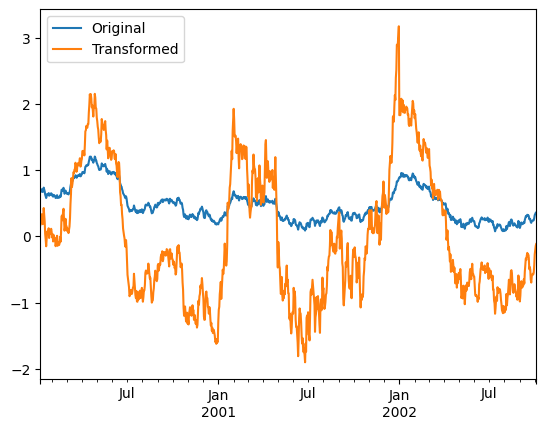

In [51]:
compare = pd.DataFrame({"Original": ts, "Transformed": transformed})
compare.plot()